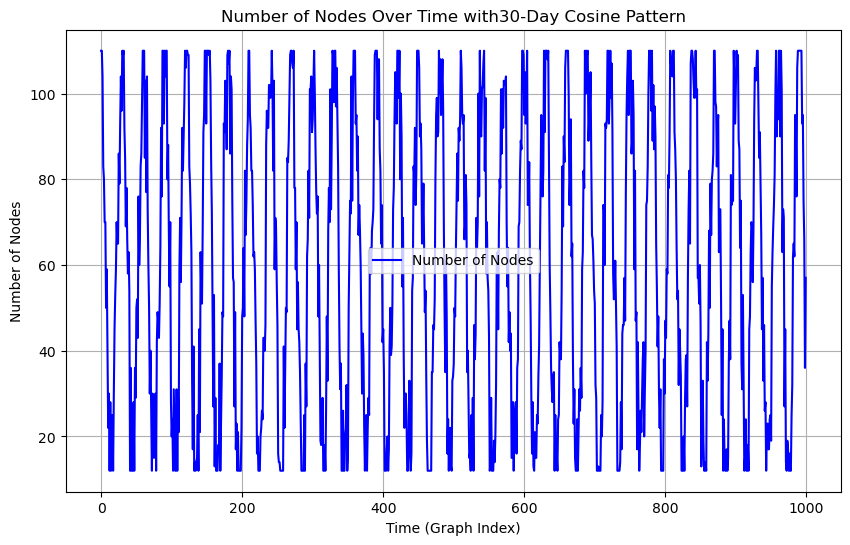

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters
num_graphs = 1000  # Adjust the number of graphs for training
max_nodes = 100  # Maximum number of nodes
period_days = 30  # Set the period of the cosine cycle to 7 "days"
start_size = 10  # Starting size for nodes

# Cosine pattern with a 7-day cycle (adjusted period for nodes)
node_pattern = (max_nodes / 2) * (1 + np.cos(2 * np.pi * np.arange(num_graphs) / period_days))

# Add randomness to the number of nodes around the cosine pattern to increase variation
num_nodes_with_randomness = [
    start_size + max(2, min(int(n + np.random.uniform(-0.2 * max_nodes, 0.2 * max_nodes)), max_nodes))
    for n in node_pattern
]

# Plot the number of nodes over time
plt.figure(figsize=(10, 6))
plt.plot(num_nodes_with_randomness, label="Number of Nodes", color="blue")
plt.title("Number of Nodes Over Time with"+str(period_days)+"-Day Cosine Pattern")
plt.xlabel("Time (Graph Index)")
plt.ylabel("Number of Nodes")
plt.grid(True)
plt.legend()
plt.show()


In [29]:
# Node activation functions for degree-based filtration
def degree_activation(degrees, threshold):
    return {node for node, degree in degrees.items() if degree >= threshold}

# Filtration function for generating embeddings (20-dimensional active data)
def graph_filtration(graph, metric, activation_func, max_degree=10):
    active_data = []
    thresholds = range(1, max_degree + 1)  # Degree thresholds from 1 to 10
    for threshold in thresholds:
        active_node_set = activation_func(metric, threshold)
        active_edges = {edge for edge in graph.edges() if edge[0] in active_node_set and edge[1] in active_node_set}
        # Each filtration gives 2 features: (number of active edges, number of active nodes)
        active_data.extend([len(active_edges), len(active_node_set)])  # 2 features per threshold
    return active_data  # 20-dimensional vector

# Process the graphs and generate embeddings (each embedding is 20-dimensional)
def process_graphs_for_embeddings(graphs):
    all_embeddings = []
    
    for i, graph in enumerate(graphs):
        metric = dict(graph.degree())  # Degree centrality as metric
        active_data = graph_filtration(graph, metric, degree_activation)
        all_embeddings.append(active_data)  # 20-dimensional embedding
    
    return all_embeddings

# Generate embeddings from synthetic graphs
embeddings = process_graphs_for_embeddings(synthetic_graphs)


In [33]:
class LSTMGRUPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(LSTMGRUPredictor, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Define LSTM layer
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        
        # Define GRU layer
        self.gru = nn.GRU(hidden_dim, hidden_dim, num_layers, batch_first=True)
        
        # Fully connected output layer
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x, hidden=None):
        # If hidden state is not provided, initialize it to zeros
        if hidden is None:
            h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)  # LSTM hidden state
            c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)  # LSTM cell state
        else:
            h0, c0 = hidden  # Unpack the hidden state
        
        # Forward pass through LSTM
        lstm_out, (h0, c0) = self.lstm(x, (h0, c0))
        
        # Forward pass through GRU (use LSTM output as input)
        gru_out, h0 = self.gru(lstm_out, h0)
        
        # Fully connected layer on the final hidden state
        out = self.fc(gru_out[:, -1, :])  # Take the last output from the sequence
        return out, (h0, c0)


In [34]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

# Assuming 'embeddings' is the full data you are working with
# Split the embeddings into training and test sets (80% train, 20% test)
train_embeddings, test_embeddings = train_test_split(embeddings, test_size=0.2, shuffle=False)

# Dataset class for embeddings with flexibility for both train and test sets
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings):
        self.embeddings = embeddings
    
    def __len__(self):
        return len(self.embeddings) - 1  # We want to predict the next embedding
    
    def __getitem__(self, idx):
        x = torch.Tensor(self.embeddings[idx]).unsqueeze(0)  # Add sequence dimension
        y = torch.Tensor(self.embeddings[idx + 1])  # Next embedding as target
        return x, y

# Create training and testing datasets and loaders
train_dataset = EmbeddingDataset(train_embeddings)
test_dataset = EmbeddingDataset(test_embeddings)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)  # Disable shuffle for time series
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# LSTM + GRU model parameters
input_dim = 20  # 20-dimensional embeddings
hidden_dim = 64
output_dim = 20  # Predict the next 20-dimensional embedding
num_layers = 4

# Define the model (assuming LSTMGRUPredictor is defined elsewhere)
model = LSTMGRUPredictor(input_dim, hidden_dim, output_dim, num_layers)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Function to train the model with proper hidden state management
def train_model():
    model.train()
    epoch_loss = 0
    for x, y in train_loader:
        optimizer.zero_grad()
        
        # Reset hidden state at the start of each sequence (batch)
        hidden = None
        output, hidden = model(x, hidden)
        
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(train_loader)

# Training loop
num_epochs = 500
for epoch in range(num_epochs):
    loss = train_model()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss}")

# Set the starting index for the test set
split_index = len(train_embeddings)  # The start of the test set time index

# Evaluation on test set with hidden state management
model.eval()
test_loss = 0
time_index = split_index  # Start time index at the beginning of the test set
with torch.no_grad():
    hidden = None  # Initialize hidden state
    for x, y in test_loader:
        output, hidden = model(x, hidden)  # Maintain hidden state across time steps
        loss = criterion(output, y)
        test_loss += loss.item()
        
        # Print time index, predicted embedding, and real embedding
        for i in range(len(x)):
            predicted_embedding = output[i].numpy()
            real_embedding = y[i].numpy()
            print(f"Time Index: {time_index}")
            print(f"Predicted Embedding: {predicted_embedding}")
            print(f"Real Embedding: {real_embedding}")
            print("-" * 50)
            time_index += 1

print(f"Test Loss: {test_loss/len(test_loader)}")


Epoch 1/500, Loss: 80776.968515625
Epoch 2/500, Loss: 78846.449921875
Epoch 3/500, Loss: 77324.211875
Epoch 4/500, Loss: 75967.35015625
Epoch 5/500, Loss: 74692.665078125
Epoch 6/500, Loss: 73474.17578125
Epoch 7/500, Loss: 72300.038828125
Epoch 8/500, Loss: 71163.530703125
Epoch 9/500, Loss: 70060.264765625
Epoch 10/500, Loss: 68987.0909375
Epoch 11/500, Loss: 67941.5790625
Epoch 12/500, Loss: 66921.758359375
Epoch 13/500, Loss: 65925.96796875
Epoch 14/500, Loss: 64952.768203125
Epoch 15/500, Loss: 64000.891484375
Epoch 16/500, Loss: 63069.204921875
Epoch 17/500, Loss: 62156.68375
Epoch 18/500, Loss: 61262.40203125
Epoch 19/500, Loss: 60385.52
Epoch 20/500, Loss: 59525.26578125
Epoch 21/500, Loss: 58680.945234375
Epoch 22/500, Loss: 57851.923828125
Epoch 23/500, Loss: 57037.625390625
Epoch 24/500, Loss: 56237.529296875
Epoch 25/500, Loss: 55451.166640625
Epoch 26/500, Loss: 54678.112421875
Epoch 27/500, Loss: 53917.987109375
Epoch 28/500, Loss: 53170.443125
Epoch 29/500, Loss: 52435.1

RuntimeError: Expected hidden[0] size (4, 7, 64), got [4, 16, 64]

In [36]:
print(y)

tensor([[486.,  81., 486.,  81., 486.,  81., 486.,  81., 486.,  81., 481.,  80.,
         475.,  79., 440.,  74., 424.,  72., 382.,  67.],
        [588.,  98., 588.,  98., 588.,  98., 588.,  98., 584.,  97., 584.,  97.,
         584.,  97., 557.,  93., 487.,  84., 420.,  76.],
        [648., 108., 648., 108., 648., 108., 648., 108., 648., 108., 648., 108.,
         642., 107., 593., 100., 547.,  94., 471.,  85.],
        [240.,  40., 240.,  40., 240.,  40., 240.,  40., 240.,  40., 240.,  40.,
         234.,  39., 234.,  39., 226.,  38., 175.,  32.],
        [144.,  24., 144.,  24., 144.,  24., 144.,  24., 144.,  24., 144.,  24.,
         144.,  24., 144.,  24., 144.,  24., 126.,  22.],
        [174.,  29., 174.,  29., 174.,  29., 174.,  29., 174.,  29., 174.,  29.,
         174.,  29., 174.,  29., 158.,  27., 133.,  24.],
        [408.,  68., 408.,  68., 408.,  68., 408.,  68., 408.,  68., 398.,  66.,
         386.,  64., 379.,  63., 340.,  58., 315.,  55.]])
